[*********************100%***********************]  1 of 1 completed


Price        Date      Close       High        Low       Open    Volume
Ticker                  AMZN       AMZN       AMZN       AMZN      AMZN
0      2020-01-02  94.900497  94.900497  93.207497  93.750000  80580000
1      2020-01-03  93.748497  94.309998  93.224998  93.224998  75288000
2      2020-01-06  95.143997  95.184502  93.000000  93.000000  81236000
3      2020-01-07  95.343002  95.694504  94.601997  95.224998  80898000
4      2020-01-08  94.598503  95.550003  94.321999  94.902000  70160000
MSE: 1.1680573218024535
R2 Score: 0.9985101250252684


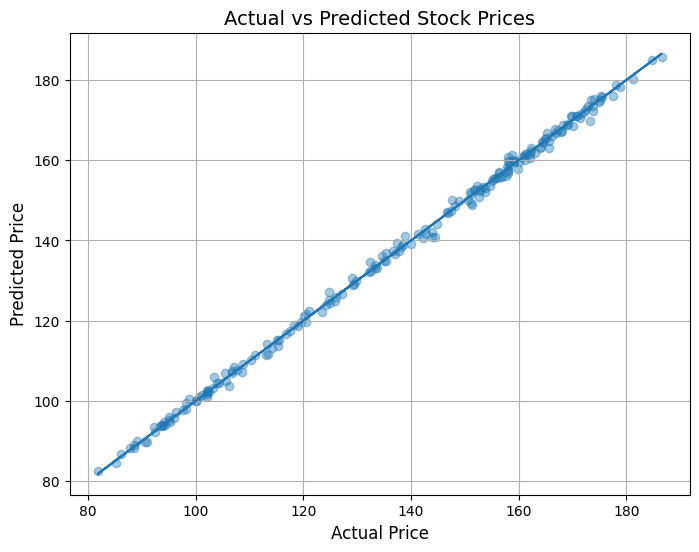

In [6]:
import pandas as pd 
#helps in hadling structured data like excel files, csv files

import numpy as np 
#performs operations of arrays,matrices,ndarrays at ease

'''sklearn = helps in building ML models, analyze data , make predictions and evaluate model performance'''
from sklearn.model_selection import train_test_split 
#helps in splitting the data into training data and test data
from sklearn.linear_model import LinearRegression 
#builds linear regression model for predicting continoues values
from sklearn.metrics import mean_squared_error, r2_score
#are used to evaluate the performance of regression models. They quantify how well a model's predictions align with the actual observed data.

import matplotlib.pyplot as plt
#Matplotlib is Python's primary library for creating a wide variety of static, interactive, and animated data visualizations

import yfinance as yf
''' yfinance is used in Python to import the yfinance library and alias it as yf for easy access to market data from Yahoo Finance. 
It allows users to download historical market data, stock prices, dividends, splits, and financial statements for research, analysis, and visualization.'''

# Download Amazon stock data
#AMZN refers to AMAZON
df = yf.download("AMZN", start="2020-01-01", end="2024-01-01")

# Reset index, here the date column is considered as ordinary column instead of main index
df.reset_index(inplace=True)

# Display first 5 rows
print(df.head())

#selection of input features as X(from which we train ) ans y (what we predict) as output variable
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Close']

#Splitting the data into trainig data which is 80% and testing data as 20%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Building a model and establishing a relationship between the input and output variables of training data
model = LinearRegression()
model.fit(X_train, y_train)

#prediction of stocks with text data
y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

plt.figure(figsize=(8, 6))

# Scatter plot
plt.scatter(y_test, y_pred, alpha=0.4)

# Perfect prediction line
plt.plot(y_test, y_test)

# Labels and title
plt.xlabel("Actual Price", fontsize=12)
plt.ylabel("Predicted Price", fontsize=12)
plt.title("Actual vs Predicted Stock Prices", fontsize=14)

# Grid for better readability
plt.grid(True)

plt.show()